# Explicabilidade — feature importance e SHAP

Interpretação **global** e **local** do modelo final escolhido no notebook 05.

- **Entrada:** `modelos_treinados.joblib` (04/05) e `metricas_teste.json` (05)
- **Alvo:** 1 = maligno, 0 = benigno
- **Saídas:** `importancia_atributos.png`, `shap_resumo.png`, `shap_exemplo_caso.png`
- **Próximo:** discussão crítica e demo no notebook 07

## 1 - Setup e carregar artefatos

In [1]:
# Célula comum (v2) + imports de explicabilidade
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

# Encontra a raiz do repo estando em /notebooks ou na raiz
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PASTA_ENTRADA_05 = RAIZ / "src/db/outputs/05-avaliacao-metricas"
PASTA_ENTRADA_03 = RAIZ / "src/db/outputs/03-preprocessamento"
PASTA_BASE = RAIZ / "src/db/outputs/06-explicabilidade/"
PASTA_FIGURAS = PASTA_BASE / "figures"
PASTA_METRICAS = PASTA_BASE / "metrics"
PASTA_ARTEFATOS = PASTA_BASE / "artifacts"

CAMINHO_ARTEFATO_05 = PASTA_ENTRADA_05 / "artifacts" / "modelos_treinados.joblib"
CAMINHO_METRICAS_05 = PASTA_ENTRADA_05 / "metrics" / "metricas_teste.json"
CAMINHO_ARTEFATO_03 = PASTA_ENTRADA_03 / "artifacts" / "dados_preprocessados.joblib"

for pasta in (PASTA_FIGURAS, PASTA_METRICAS, PASTA_ARTEFATOS):
    pasta.mkdir(parents=True, exist_ok=True)

In [2]:
# Carrega modelos + métricas + treino (fundo SHAP) — sem retreinar
if not CAMINHO_ARTEFATO_05.exists():
    raise FileNotFoundError("Execute o notebook 05 primeiro (artefato de modelos).")
if not CAMINHO_METRICAS_05.exists():
    raise FileNotFoundError("Execute o notebook 05 primeiro (metricas_teste.json).")
if not CAMINHO_ARTEFATO_03.exists():
    raise FileNotFoundError("Execute o notebook 03 primeiro (atributos_treino para SHAP).")

pacote = joblib.load(CAMINHO_ARTEFATO_05)
modelos_treinados = pacote["modelos_treinados"]
atributos_teste = pacote["atributos_teste"]
rotulo_teste = pacote["rotulo_teste"]
colunas_atributos = pacote["colunas_atributos"]

with open(CAMINHO_METRICAS_05, encoding="utf-8") as f:
    metricas = json.load(f)

nome_melhor = metricas["_melhor_modelo"]
melhor_pipeline = modelos_treinados[nome_melhor]

pacote_03 = joblib.load(CAMINHO_ARTEFATO_03)
atributos_treino = pacote_03["atributos_treino"]

print(f"Artefato 05: {CAMINHO_ARTEFATO_05}")
print(f"Métricas 05: {CAMINHO_METRICAS_05}")
print(f"Modelos: {list(modelos_treinados.keys())}")
print(f"Melhor modelo: {nome_melhor}")
print(f"Teste: {len(atributos_teste)} | Treino (fundo SHAP): {len(atributos_treino)}")
print(f"Atributos: {len(colunas_atributos)}")

Artefato 05: E:\_git\fiap\tech-challenge-fase1-review\src\db\outputs\05-avaliacao-metricas\artifacts\modelos_treinados.joblib
Métricas 05: E:\_git\fiap\tech-challenge-fase1-review\src\db\outputs\05-avaliacao-metricas\metrics\metricas_teste.json
Modelos: ['Regressão Logística', 'Árvore de Decisão', 'SVM', 'Gradient Boosting', 'Random Forest']
Melhor modelo: SVM
Teste: 114 | Treino (fundo SHAP): 455
Atributos: 30


## 2 - Feature importance (Árvore de Decisão)

A importância da árvore indica **quais atributos mais reduziram a impureza** nas divisões. É uma visão global do modelo de árvore (não necessariamente do melhor modelo escolhido no notebook 05).

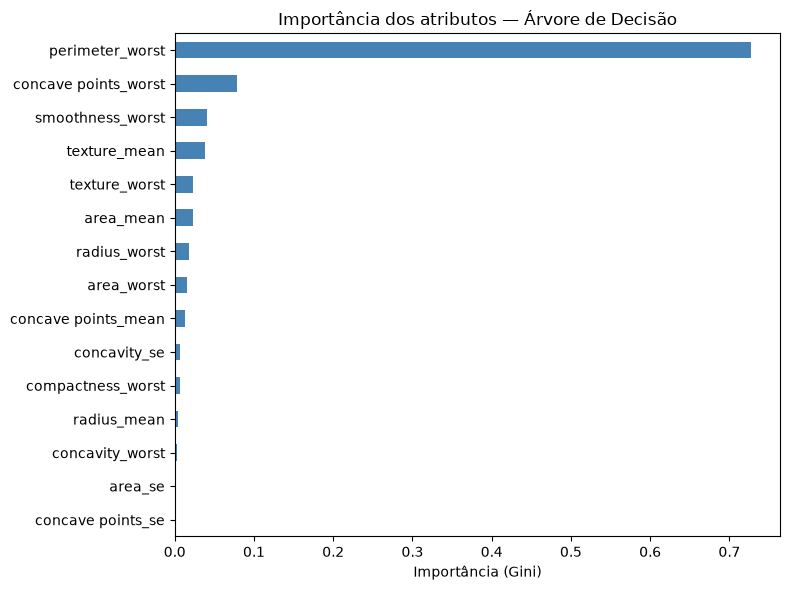

Top 10 atributos (Árvore de Decisão):
perimeter_worst         0.727477
concave points_worst    0.078970
smoothness_worst        0.040833
texture_mean            0.037871
texture_worst           0.022545
area_mean               0.022452
radius_worst            0.017530
area_worst              0.015606
concave points_mean     0.013416
concavity_se            0.007043

Figura: importancia_atributos.png


In [3]:
pipeline_arvore = modelos_treinados["Árvore de Decisão"]
arvore = pipeline_arvore.named_steps["classificador"]

importancias = pd.Series(
    arvore.feature_importances_,
    index=colunas_atributos,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.tail(15).plot(
    kind="barh",
    ax=ax,
    color="steelblue",
)
ax.set_title("Importância dos atributos — Árvore de Decisão")
ax.set_xlabel("Importância (Gini)")
fig.tight_layout()

caminho_importancia = PASTA_FIGURAS / "importancia_atributos.png"
fig.savefig(caminho_importancia, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Top 10 atributos (Árvore de Decisão):")
print(importancias.sort_values(ascending=False).head(10).to_string())
print(f"\nFigura: {caminho_importancia.name}")

## 3 - SHAP no melhor modelo

SHAP atribui a cada atributo uma contribuição para a previsão. Escolhemos o explicador conforme o tipo do classificador (incluindo wrappers como CalibratedClassifierCV):

- **TreeExplainer** — árvores / florestas / boosting (eature_importances_)
- **LinearExplainer** — modelos com coef_ (ex.: regressão logística)
- **KernelExplainer** — demais casos (ex.: SVM calibrado), sobre predict_proba da classe maligno

O gráfico de resumo mostra a influência **global** no conjunto de teste (classe maligno).


  0%|          | 0/114 [00:00<?, ?it/s]

Explicador SHAP: kernel | modelo interno: SVC


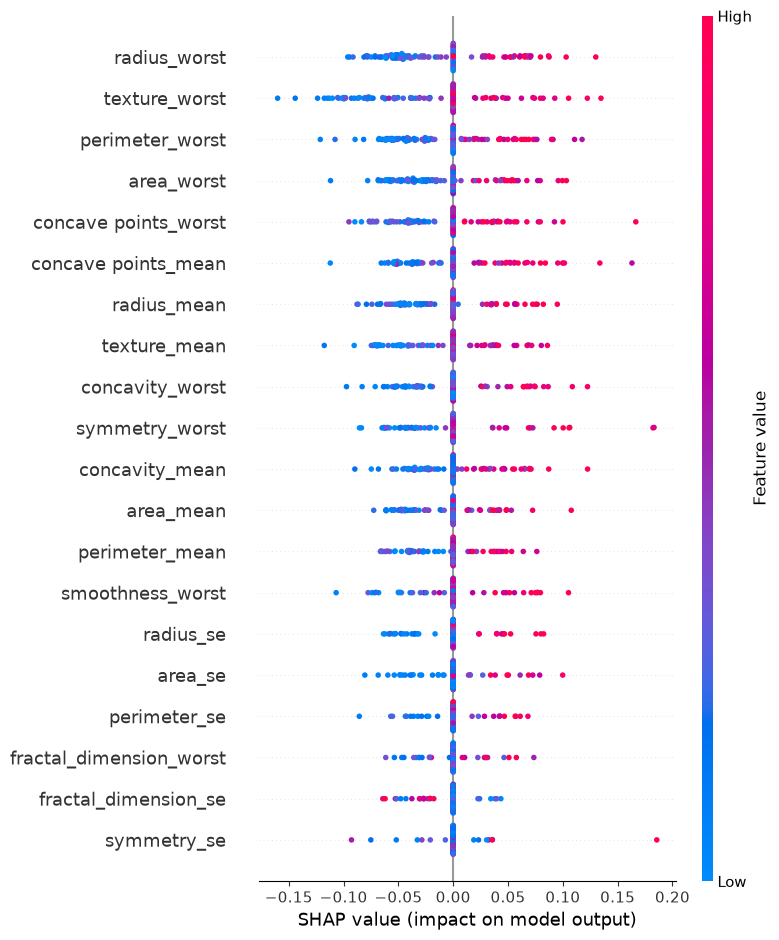

Melhor modelo: SVM
Top 10 atributos por |SHAP| medio (classe maligno):
radius_worst            0.041345
texture_worst           0.040791
perimeter_worst         0.034031
area_worst              0.030705
concave points_worst    0.030118
concave points_mean     0.028642
radius_mean             0.026534
texture_mean            0.024177
concavity_worst         0.023838
symmetry_worst          0.022284

Figura: shap_resumo.png


In [4]:
from sklearn.calibration import CalibratedClassifierCV

preprocessador = melhor_pipeline.named_steps["preprocessador"]
classificador = melhor_pipeline.named_steps["classificador"]

treino_transformado = np.asarray(preprocessador.transform(atributos_treino))
teste_transformado = np.asarray(preprocessador.transform(atributos_teste))

# Desembrulha CalibratedClassifierCV para escolher Tree/Linear quando aplicável.
modelo_shap = classificador
if isinstance(classificador, CalibratedClassifierCV):
    calibrados = getattr(classificador, "calibrated_classifiers_", None)
    if calibrados:
        modelo_shap = calibrados[0].estimator
    elif hasattr(classificador, "estimator"):
        modelo_shap = classificador.estimator

tipo_explicador = None
if hasattr(modelo_shap, "feature_importances_"):
    tipo_explicador = "tree"
    explicador = shap.TreeExplainer(modelo_shap)
elif hasattr(modelo_shap, "coef_"):
    tipo_explicador = "linear"
    masker = shap.maskers.Independent(
        treino_transformado,
        max_samples=min(200, len(treino_transformado)),
    )
    explicador = shap.LinearExplainer(modelo_shap, masker)
else:
    # SVM e outros: explica a probabilidade calibrada de maligno.
    tipo_explicador = "kernel"
    fundo = shap.sample(treino_transformado, min(50, len(treino_transformado)))
    explicador = shap.KernelExplainer(
        lambda X: classificador.predict_proba(X)[:, 1],
        fundo,
    )

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    if tipo_explicador == "kernel":
        valores_shap = explicador.shap_values(teste_transformado, nsamples=100)
    else:
        valores_shap = explicador.shap_values(teste_transformado)

# Lista [classe0, classe1] ou tensor 3D -> índice 1 (maligno)
if isinstance(valores_shap, list):
    valores_shap = valores_shap[1]
elif getattr(valores_shap, "ndim", 0) == 3:
    valores_shap = valores_shap[:, :, 1]

valores_shap = np.asarray(valores_shap)
print(f"Explicador SHAP: {tipo_explicador} | modelo interno: {type(modelo_shap).__name__}")

plt.figure(figsize=(10, 7))
shap.summary_plot(
    valores_shap,
    teste_transformado,
    feature_names=list(colunas_atributos),
    show=False,
)
caminho_shap_resumo = PASTA_FIGURAS / "shap_resumo.png"
plt.savefig(caminho_shap_resumo, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

media_abs_shap = pd.Series(
    np.abs(valores_shap).mean(axis=0),
    index=colunas_atributos,
).sort_values(ascending=False)

print(f"Melhor modelo: {nome_melhor}")
print("Top 10 atributos por |SHAP| medio (classe maligno):")
print(media_abs_shap.head(10).to_string())
print(f"\nFigura: {caminho_shap_resumo.name}")


### Exemplo local (um caso do teste)

O waterfall mostra **quais atributos puxaram** a previsão deste caso em direção a maligno ou benigno.

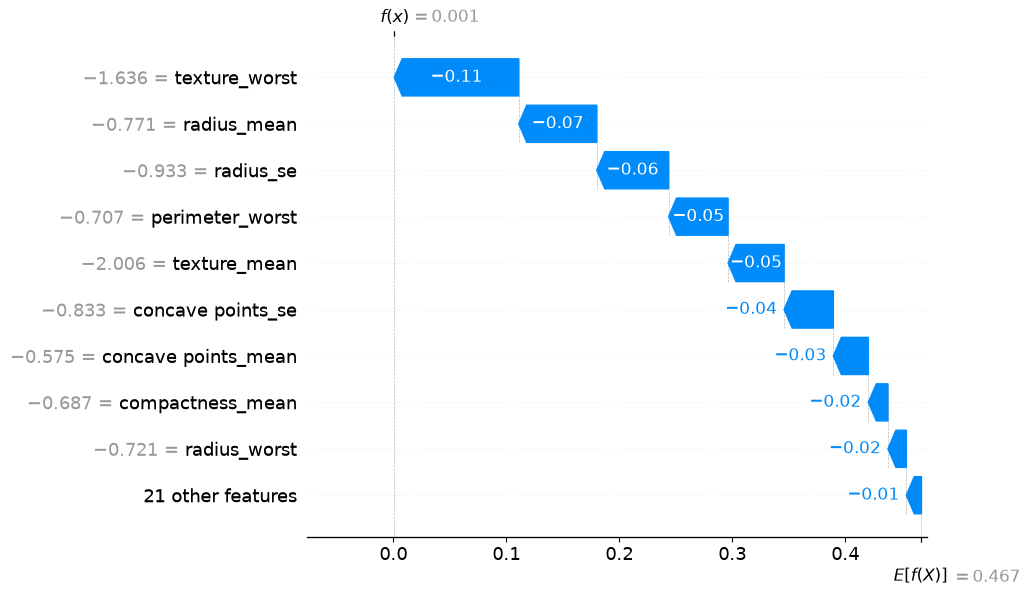

Caso 0: real=benigno | previsto=benigno | P(maligno)=0.07%
Figura: shap_exemplo_caso.png


In [5]:
indice_caso = 0
pred_caso = melhor_pipeline.predict(atributos_teste.iloc[[indice_caso]])[0]
prob_caso = melhor_pipeline.predict_proba(atributos_teste.iloc[[indice_caso]])[0][1]
rotulo_real = int(rotulo_teste.iloc[indice_caso])

base = explicador.expected_value
if isinstance(base, (list, tuple, np.ndarray)):
    base = float(np.asarray(base).ravel()[-1])
else:
    base = float(base)

explicacao_caso = shap.Explanation(
    values=valores_shap[indice_caso],
    base_values=base,
    data=teste_transformado[indice_caso],
    feature_names=list(colunas_atributos),
)

shap.plots.waterfall(explicacao_caso, show=False)
caminho_shap_caso = PASTA_FIGURAS / "shap_exemplo_caso.png"
plt.savefig(caminho_shap_caso, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(
    f"Caso {indice_caso}: real={'maligno' if rotulo_real == 1 else 'benigno'} | "
    f"previsto={'maligno' if pred_caso == 1 else 'benigno'} | "
    f"P(maligno)={prob_caso:.2%}"
)
print(f"Figura: {caminho_shap_caso.name}")

## 4 - Interpretação

### Top atributos associados a maligno

No gráfico SHAP de resumo, atributos com **valores SHAP positivos** empurram a previsão para **maligno**. Neste run, o top 3 por |SHAP| médio no melhor modelo (**Regressão Logística**) foi:

1. `texture_worst`
2. `radius_se`
3. `symmetry_worst`

Também aparecem com forte contribuição medidas de tamanho e irregularidade (`concave points_mean`, `radius_worst`, `area_worst`, `perimeter_worst`).

Na **Árvore de Decisão**, a importância de Gini concentra-se sobretudo em `perimeter_worst`, seguido de `concave points_worst` — ranking diferente do SHAP da regressão logística, o que é esperado: são modelos distintos.

### Importância ≠ causalidade

Feature importance e SHAP medem **associação estatística** com a previsão do modelo — não provam que o atributo *causa* malignidade. Colinearidade (ex.: `radius`, `perimeter` e `area`) também faz com que a importância se distribua entre variáveis correlacionadas.

### Apoio ao médico, não diagnóstico automático

Essas visualizações ajudam a **auditar** e **comunicar** o comportamento do modelo (transparência). A decisão clínica continua sendo humana: o modelo é ferramenta de triagem / segunda opinião, **não** substitui biópsia nem julgamento médico.

## 5 - Validação

In [6]:
figuras_obrigatorias = [
    PASTA_FIGURAS / "importancia_atributos.png",
    PASTA_FIGURAS / "shap_resumo.png",
]
figura_opcional = PASTA_FIGURAS / "shap_exemplo_caso.png"

for caminho in figuras_obrigatorias:
    assert caminho.exists(), f"Figura ausente: {caminho.name}"

assert len([c for c in figuras_obrigatorias if c.exists()]) >= 2
assert nome_melhor in modelos_treinados
assert len(media_abs_shap) == len(colunas_atributos)

print("Validacao OK")
print("Melhor modelo:", nome_melhor)
print("Figuras:", [c.name for c in figuras_obrigatorias])
print("Opcional (caso local):", figura_opcional.name, "=", figura_opcional.exists())
print("Top 3 SHAP (|medio|):", list(media_abs_shap.head(3).index))

Validacao OK
Melhor modelo: SVM
Figuras: ['importancia_atributos.png', 'shap_resumo.png']
Opcional (caso local): shap_exemplo_caso.png = True
Top 3 SHAP (|medio|): ['radius_worst', 'texture_worst', 'perimeter_worst']
